# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [16]:
import random

class Card:
    def __init__(self, suit, val):
        self.suit= suit
        self.val =val
        
    def __str__(self):
        return str(self.val) +" of " +self.suit

In [17]:
import random  #shuffle the deck randomly

class Card:
    def __init__(self, suit, val):
        #each card with a suit and a value
        self.suit = suit   # hearts, diamonds, clubs, spades
        self.val = val     # 2-10, J, Q, K, A
        
    def __str__(self):
        # defines how the card will be printed
        return str(self.val) + " of " + self.suit


class Deck:
    
    def __init__(self, num_decks=6):
        # default is 6 decks (like a real casino blackjack game)
        
        suits = ["hearts", "diamonds", "clubs", "spades"]  # all suits
        vals = [2,3,4,5,6,7,8,9,10,"J","Q","K","A"]        # all values
        
        self.cards = []  # list to store all card objects
        
        #create multiple decks
        for d in range(num_decks):  # loop for number of decks
            for s in suits:         # loop through each suit
                for v in vals:      # loop through each value
                    self.cards.append(Card(s, v))
        
        # shuffle the deck so cards are in random order
        random.shuffle(self.cards)
        
        # create a "cut card" at 75% of the deck
        # when it is reached, the deck should be reshuffled later
        self.cut_card = int(len(self.cards) * 0.75)
        
    def shuffle(self):
        # reshuffle the deck at any time
        random.shuffle(self.cards)
        
    def draw(self):
        # draw a card from the deck
        
        if len(self.cards) == 0:
            # if no cards left, return to None
            return None
        
        # remove and return the last card in the deck
        return self.cards.pop()

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

Card
Deck -> contains many Cards
Hand -> contains Cards
Player -> has a Hand
Dealer -> subclass of Player
Game -> controls players, dealer, and deck

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [7]:
class Hand:
    
    def __init__(self):
        self.cards = []
        
    def add(self, card):
        # this method will add a card to the hand
        pass
    
    def value(self):
        # this method will calculate the total value of the hand
        # needed for blackjack scoring (handle A as 1 or 11 later)
        pass


class Player:
    
    def __init__(self, name, chips=1000):
        # initialize player with a name and starting chips
        self.name = name
        
        # number of chips the player has (used for betting)
        self.chips = chips
        
        # each player starts with an empty hand
        self.hand = Hand()
        
    def bet(self):
        # this method will decide how much the player bets each round
        # could be fixed or strategy-based
        # logic not implemented yet
        pass
    
    def play(self, deck):
        # this method defines how the player plays their turn
        # (hit, stand, etc.)
        # deck is passed so player can draw cards
        # logic not implemented yet
        pass


class Dealer(Player):
    
    def play(self, deck):
        # dealer's play behavior (follows fixed rules like hit on 16)
        # overrides Player's play() method
        # logic not implemented yet
        pass


class Game:
    
    def __init__(self, players):
        # list of players in the game
        self.players = players
        
        # create a deck (default is 6 decks)
        self.deck = Deck()
        
    def round(self):
        # this method will run one full round of blackjack
        # includes dealing cards, player turns, dealer turn, and results
        # logic not implemented yet
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [8]:
class Hand:
    
    def __init__(self):
        # list to store all cards in the hand
        self.cards = []
        
    def add(self, card):
        # add a new card to the hand
        self.cards.append(card)
        
    def value(self):
        # calculate the total value of the hand
        
        total = 0   # total value of the hand
        aces = 0    # count how many aces we have
        
        for c in self.cards:
            
            # face cards are worth 10
            if c.val in ["J","Q","K"]:
                total += 10
                
            # aces are initially counted as 11
            elif c.val == "A":
                total += 11
                aces += 1
                
            # number cards keep their value
            else:
                total += c.val
                
        # if total is over 21 and we have aces,
        # convert ace from 11 to 1 (subtract 10)
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
            
        return total
        

class Player:
    
    def __init__(self, name, chips=1000):
        # player name
        self.name = name
        
        # starting chips
        self.chips = chips
        
        # each player has a hand
        self.hand = Hand()
        
    def bet(self):
        # for now, player always bets 10 chips
        return 10
        
    def play(self, deck):
        # player strategy: keep drawing until value is at least 17
        
        while self.hand.value() < 17:
            # draw a card from the deck and add to hand
            self.hand.add(deck.draw())


class Dealer(Player):
    
    def __init__(self):
        # dealer has a fixed name and large chip amount
        super().__init__("dealer", 999999)
        
    def play(self, deck):
        # dealer follows standard blackjack rule:
        # hit until reaching 17 or higher
        
        while self.hand.value() < 17:
            self.hand.add

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [9]:
# create 3 players with different names
p1 = Player("bob")
p2 = Player("goofy")
p3 = Player("weirdguy")

# create a game and pass in the list of players
g = Game([p1, p2, p3])

# run 5 rounds of the game
for i in range(5):
    # each loop runs one full blackjack round
    g.round()

# print the final chip counts for each player after 5 rounds
print(p1.chips, p2.chips, p3.chips)

1000 1000 1000


6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [10]:
class CounterPlayer(Player):
    
    def __init__(self, name, thresh=3):
        # initialize the player using the parent (Player) class
        super().__init__(name)
        
        # running count of seen cards
        self.count = 0
        
        # threshold to decide when to bet higher
        self.thresh = thresh
        
    def see_card(self, card):
        # update the running count based on the card seen
        
        # low cards (2–6) increase the count
        # this is good for the player (more high cards left in deck)
        if card.val in [2,3,4,5,6]:
            self.count += 1
            
        # high cards (10, face cards, Ace) decrease the count
        # this is bad for the player (fewer high cards left)
        elif card.val in [10,"J","Q","K","A"]:
            self.count -= 1
            
        # cards 7–9 do not affect the count (value = 0)
            
            
    def bet(self):
        # decide how much to bet based on the current count
        
        # if count is high (favorable situation), bet more
        if self.count >= self.thresh:
            return 50
        
        # otherwise, bet the minimum
        else:
            return 10



7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [11]:
# create a counter player with threshold = 3
# this player will use card counting strategy
counter = CounterPlayer("counterdude", 3)

# create regular players (no strategy, basic behavior)
p1 = Player("npc1")
p2 = Player("npc2")
p3 = Player("npc3")

# create the game with all players included
g = Game([counter, p1, p2, p3])

# run 50 rounds of blackjack
for i in range(50):
    # each round simulates a full game (deal, play, results)
    g.round()

# print the final chip count of the counter player
# used to evaluate if the strategy is effective
print("counter chips:", counter.chips)

counter chips: 1000


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


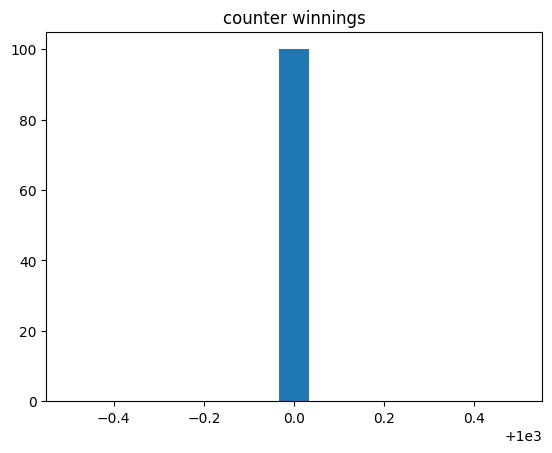

In [12]:
import matplotlib.pyplot as plt  # used to create the histogram

wins = []  # list to store final chip counts from each game

# run 100 separate games
for game in range(100):
    
    # create a new counter player for each game
    counter = CounterPlayer("countbro", 3)
    
    # create 3 normal players
    p1 = Player("a")
    p2 = Player("b")
    p3 = Player("c")
    
    # create a new game instance
    g = Game([counter, p1, p2, p3])
    
    # run 50 rounds per game
    for r in range(50):
        g.round()
        
    # store the counter player's final chips after 50 rounds
    wins.append(counter.chips)

# create a histogram of winnings
plt.hist(wins, bins=15)  # bins control how many bars in the histogram
plt.title("counter winnings")
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [13]:
# list of threshold values to test
tests = [1, 2, 3, 4, 5]

# loop through each threshold value
for t in tests:
    
    stuff = []  # store results (final chips) for this threshold
    
    # run 50 games for each threshold
    for game in range(50):
        
        # create a counter player with current threshold t
        counter = CounterPlayer("guy", t)
        
        # create normal players
        p1 = Player("x")
        p2 = Player("y")
        p3 = Player("z")
        
        # create game with all players
        g = Game([counter, p1, p2, p3])
        
        # play 50 rounds per game
        for r in range(50):
            g.round()
            
        # store final chip count for this game
        stuff.append(counter.chips)
    
    # calculate and print average chips for this threshold
    print("threshold", t, "avg", sum(stuff) / len(stuff))

threshold 1 avg 1000.0
threshold 2 avg 1000.0
threshold 3 avg 1000.0
threshold 4 avg 1000.0
threshold 5 avg 1000.0


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [15]:
class AggroPlayer(Player):
    
    def bet(self):
        
        if self.hand.value() >= 15:
            return 30
        else:
            return 10